# FIT5196 Ass2 2026 中文从零讲解 Notebook

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

ROOT = Path.cwd()
print('Current working directory:', ROOT)
print('pandas version:', pd.__version__)
print('numpy version:', np.__version__)

Current working directory: /Users/songhaifan/Documents/GitHub/teaching-materials/courses/lincoin/materials/fit5196/ass2_2026
pandas version: 3.0.1
numpy version: 2.4.3


在正式读数据之前，我们先回答三个问题。

### 1. Task 1 要交什么？

Task 1 是 **Data Cleansing**，需要提交 5 个文件：

- `Group024_dirty_data_solution.csv`
- `Group024_missing_data_solution.csv`
- `Group024_outlier_data_solution.csv`
- `Group024_ass2_task1.ipynb`
- `Group024_ass2_task1.py`

其中 `.ipynb` 要展示完整方法、过程、解释和输出；`.py` 主要用于 plagiarism checking。

### 2. 哪三个 CSV 分别做什么？

| 文件 | 我们要做什么 | 关键限制 |
|---|---|---|
| `Group024_dirty_data.csv` | 找出并修复错误值 | 每一行最多只有一个 anomaly；每个 anomaly 只有一个正确修法 |
| `Group024_missing_data.csv` | 填补缺失值 | 只有 coverage / missing anomalies，没有其他脏数据问题 |
| `Group024_outlier_data.csv` | 删除 outlier rows | 只针对 `delivery_fee` 判断 outlier，删除整行，不是改值 |

所以这三个文件不能用同一套粗暴方法处理。它们代表三类不同的数据质量问题。

### 3. 哪些列不能乱改？

题目明确说，在 dirty data 里不要找这些列的错误：

- `order_id`
- `time`
- `order_items` 里的 **数量**
- `delivery_fee`

注意：`order_items` 里的 item name 可能有问题，但 quantity 不应该改。  
`delivery_fee` 在 dirty data 里不改；它只在 missing / outlier 任务里发挥作用。

### 课堂提醒

这一步非常重要。我们不是看到奇怪值就改，而是先根据 assignment guide 定义“什么可以改、什么不能改”。这就是 FIT5196 Week 7-8 讲的数据质量审计思路。

## 0. Assignment-given constraints first

<details open>
<summary><strong>展开 / 收起：assignment PDF 已经给出的规则</strong></summary>

在正式 EDA 之前，先把 assignment PDF 已经给出的规则翻译成 data constraints。这样后面的检查不是“碰运气找异常”，而是验证哪些 rows 违反了已知规则。

| Rule from assignment | How we use it from the start |
| --- | --- |
| Dirty data 每行最多一个 anomaly | 使用 issue tracker；每行只接受一个最终修复原因 |
| Dirty data 的 `order_id`, `time`, `delivery_fee`, item quantities 是 error-free | 不修改这些字段；用 `order_id` 推 `branch_code`，用 `time` 推 `order_type` |
| Missing data 只有 coverage/missing anomalies | 非缺失字段可作为干净参考；用 missing 文件内部非缺失 `delivery_fee` 训练模型 |
| Outlier data 只有 `delivery_fee` outliers | 不修其他字段；只检测并删除 delivery fee outlier rows |
| `customer_lat/customer_lon` 来自 `nodes.csv` | 坐标应能 exact match 到 node；优先检查 sign flip 和 lat/lon swap |
| `distance_to_customer_KM` 是 Dijkstra shortest path | 使用 `edges.csv` 的 `distance(m)` 作为 graph weight，不用 straight-line distance |
| `delivery_fee` branch-specific 且线性依赖 weekend/time/distance | 每个 branch 单独训练 linear model，并加入 `is_weekend`, `time_code`, `distance_to_customer_KM` |
| Loyalty customer 有 50% delivery fee discount | 建模前还原 undiscounted fee，预测后再应用折扣 |

所以这个 clean notebook 的顺序是：先声明规则，再做 EDA，再按 dependency 顺序修复和验证。

</details>

![alt text](dependency.svg)

In [2]:
from pathlib import Path
from datetime import datetime
import ast

import networkx as nx
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

from task1_clean_tools import Task1NotebookTools

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

DATA_DIR = Path(".")
task = Task1NotebookTools(DATA_DIR)


## 1.1 How the helper works

`Task1NotebookTools` 是一个很薄的 helper。它不决定哪个 attribute 错，也不决定应该怎么修；这些判断都写在 notebook 里。

它主要帮我们统一做五件事：

1. 保存原始数据和 working copy；
2. 对 dirty data 维护 one-anomaly tracker；
3. 根据我们传入的 `issue_mask` 和 `replacements` 应用修复；
4. 打印 `flagged / fixed / remaining / skipped_by_tracker`；
5. 展示 before/after sample，最后导出 CSV。

核心调用长这样：

```python
task.fix_values(
    dataset="dirty",
    step="branch_code",
    issue_mask=branch_issue,
    replacements={"branch_code": expected_branch},
    sample_columns=["branch_code"],
    remaining_check=lambda df: ...,
)
```

参数含义：

| Parameter | Meaning |
| --- | --- |
| `dataset` | 当前处理哪个数据集：`dirty`, `missing`, `outlier` |
| `step` | 当前修哪个 attribute，也会写进 tracker/log |
| `issue_mask` | 一个 True/False Series，表示哪些 rows 被怀疑有这个问题 |
| `replacements` | 一个 dict，key 是要改的 column，value 是 replacement Series 或固定值 |
| `sample_columns` | before/after 展示哪些 columns |
| `remaining_check` | 修完后重新检查还有多少同类问题 |

对 dirty data，helper 会额外做一件事：如果某行已经被前面某一步修过，它不会再被后面的步骤改动，而是计入 `skipped_by_tracker`。这正好对应 assignment rule：dirty data 每行最多一个 anomaly。


In [3]:
task.overview()

Loaded Task 1 files.


,dataset,rows,columns,missing_cells,duplicated_order_id
0,dirty,500,12,0,0
1,missing,500,12,200,0
2,outlier,500,12,0,0


In [4]:
task.column_summary("dirty")

[dirty] rows=500, columns=12


,column,dtype,missing,unique
0,order_id,str,0,500
1,date,str,0,295
2,time,str,0,72
3,order_type,str,0,3
4,branch_code,str,0,6
5,order_items,str,0,499
6,order_price,float64,0,428
7,customer_lat,float64,0,493
8,customer_lon,float64,0,493
9,customerHasloyalty?,int64,0,2


In [5]:
PREFIX_TO_BRANCH = {
    **dict.fromkeys(list("AKX"), "BK"),
    **dict.fromkeys(list("BJY"), "TP"),
    **dict.fromkeys(list("CIZ"), "NS"),
}

MENU = {
    "Breakfast": {"Cereal": 21.00, "Coffee": 7.50, "Eggs": 22.00, "Pancake": 24.25},
    "Lunch": {"Burger": 31.00, "Chicken": 32.00, "Fries": 12.00, "Salad": 17.20, "Steak": 45.00},
    "Dinner": {"Fish&Chips": 35.00, "Pasta": 27.50, "Salmon": 41.00, "Shrimp": 54.00},
}

TIME_CODE = {"Breakfast": 0, "Lunch": 1, "Dinner": 2}


def branch_from_order_id(order_id):
    return PREFIX_TO_BRANCH[str(order_id)[3]]


def parse_items(value):
    return ast.literal_eval(value)


def format_items(items):
    return str([(str(item), int(quantity)) for item, quantity in items])


def item_total(items, order_type):
    return round(sum(MENU[order_type][item] * quantity for item, quantity in items), 2)


def expected_order_price(row):
    return item_total(parse_items(row["order_items"]), row["order_type"])


In [6]:
dirty = task.start("dirty")

[dirty:start] protected columns: order_id, time, delivery_fee, item quantities


### 5.1 branch_code

`order_id` prefix 决定 expected branch。这里同时覆盖大小写错误和 prefix mismatch。

In [7]:
PREFIX_TO_BRANCH

{'A': 'BK',
 'K': 'BK',
 'X': 'BK',
 'B': 'TP',
 'J': 'TP',
 'Y': 'TP',
 'C': 'NS',
 'I': 'NS',
 'Z': 'NS'}

In [8]:
expected_branch = dirty["order_id"].map(branch_from_order_id)
branch_issue = dirty["branch_code"].astype(str).ne(expected_branch)

task.fix_values(
    dataset="dirty",
    step="branch_code",
    issue_mask=branch_issue,
    replacements={"branch_code": expected_branch},
    sample_columns=["branch_code"],
    remaining_check=lambda df: df["branch_code"].astype(str).ne(df["order_id"].map(branch_from_order_id)),
)

[dirty:branch_code] flagged=37, fixed=37, remaining=0, skipped_by_tracker=0


,order_id_before,branch_code_before,order_id_after,branch_code_after
4,ORDK03173,tp,ORDK03173,BK
21,ORDI09297,BK,ORDI09297,NS
22,ORDC07228,TP,ORDC07228,NS
31,ORDK06897,ns,ORDK06897,BK
33,ORDA05281,tp,ORDA05281,BK
48,ORDI09968,tp,ORDI09968,NS
52,ORDK07377,ns,ORDK07377,BK
74,ORDK04119,NS,ORDK04119,BK


### 5.2 date

把多种可解释的日期格式统一成 `YYYY-MM-DD`。

In [9]:
DATE_FORMATS = ("%Y-%m-%d", "%Y-%d-%m", "%m-%d-%Y")


def clean_date(value):
    for date_format in DATE_FORMATS:
        parsed = pd.to_datetime(value, format=date_format, errors="coerce")
        if pd.notna(parsed) and parsed.year == 2018:
            return parsed.strftime("%Y-%m-%d")
    return pd.NaT


In [10]:
canonical_date = dirty["date"].map(clean_date)
date_issue = canonical_date.ne(dirty["date"])

task.fix_values(
    dataset="dirty",
    step="date",
    issue_mask=date_issue,
    replacements={"date": canonical_date},
    sample_columns=["date"],
    remaining_check=lambda df: df["date"].map(clean_date).ne(df["date"]),
)

[dirty:date] flagged=37, fixed=37, remaining=0, skipped_by_tracker=0


,order_id_before,date_before,order_id_after,date_after
0,ORDX00699,03-08-2018,ORDX00699,2018-03-08
10,ORDC01147,2018-26-08,ORDC01147,2018-08-26
16,ORDK04564,2018-19-09,ORDK04564,2018-09-19
18,ORDY05205,04-01-2018,ORDY05205,2018-04-01
37,ORDJ05383,2018-18-08,ORDJ05383,2018-08-18
42,ORDJ08299,02-09-2018,ORDJ08299,2018-02-09
51,ORDB00774,2018-16-06,ORDB00774,2018-06-16
70,ORDB07017,04-07-2018,ORDB07017,2018-04-07


### 5.3 order_type

`time` 是 protected，所以用 meal window 反推 `order_type`。

In [11]:
def order_type_from_time(value):
    hour, minute, second = map(int, str(value).split(":"))
    total_seconds = hour * 3600 + minute * 60 + second

    if 8 * 3600 <= total_seconds <= 12 * 3600:
        return "Breakfast"
    if 12 * 3600 < total_seconds <= 16 * 3600:
        return "Lunch"
    if 16 * 3600 < total_seconds <= 20 * 3600:
        return "Dinner"
    return np.nan


In [12]:
expected_type = dirty["time"].map(order_type_from_time)
order_type_issue = dirty["order_type"].ne(expected_type)

task.fix_values(
    dataset="dirty",
    step="order_type",
    issue_mask=order_type_issue,
    replacements={"order_type": expected_type},
    sample_columns=["time", "order_type"],
    remaining_check=lambda df: df["order_type"].ne(df["time"].map(order_type_from_time)),
)

[dirty:order_type] flagged=37, fixed=37, remaining=0, skipped_by_tracker=0


,order_id_before,time_before,order_type_before,order_id_after,time_after,order_type_after
23,ORDX10183,18:28:43,Lunch,ORDX10183,18:28:43,Dinner
28,ORDY07273,13:34:38,Breakfast,ORDY07273,13:34:38,Lunch
43,ORDK02724,13:24:30,Breakfast,ORDK02724,13:24:30,Lunch
45,ORDI00689,12:33:48,Breakfast,ORDI00689,12:33:48,Lunch
67,ORDJ03210,08:20:16,Lunch,ORDJ03210,08:20:16,Breakfast
69,ORDJ10027,12:23:39,Breakfast,ORDJ10027,12:23:39,Lunch
95,ORDK04641,10:01:41,Lunch,ORDK04641,10:01:41,Breakfast
108,ORDJ06140,12:03:22,Breakfast,ORDJ06140,12:03:22,Lunch


### 5.4 customer coordinates

Melbourne customers only，且 customer coordinates 来自 `nodes.csv`。明显问题是 latitude 正负号错误，或 lat/lon 被交换。

In [13]:
swap_issue = dirty["customer_lat"].gt(90) & dirty["customer_lon"].lt(0)
sign_issue = dirty["customer_lat"].between(0, 90)
coordinate_issue = swap_issue | sign_issue

new_lat = dirty["customer_lat"].copy()
new_lon = dirty["customer_lon"].copy()

new_lat.loc[swap_issue] = dirty.loc[swap_issue, "customer_lon"]
new_lon.loc[swap_issue] = dirty.loc[swap_issue, "customer_lat"]
new_lat.loc[sign_issue] = -dirty.loc[sign_issue, "customer_lat"]

task.fix_values(
    dataset="dirty",
    step="customer_coordinates",
    issue_mask=coordinate_issue,
    replacements={"customer_lat": new_lat, "customer_lon": new_lon},
    sample_columns=["customer_lat", "customer_lon"],
    remaining_check=lambda df: df["customer_lat"].gt(0) | df["customer_lon"].lt(0),
)

[dirty:customer_coordinates] flagged=41, fixed=41, remaining=0, skipped_by_tracker=0


,order_id_before,customer_lat_before,customer_lon_before,order_id_after,customer_lat_after,customer_lon_after
32,ORDZ03318,37.8062,144.9395,ORDZ03318,-37.8062,144.9395
38,ORDZ06323,37.8142,144.9610,ORDZ06323,-37.8142,144.9610
57,ORDK02131,37.8056,144.9487,ORDK02131,-37.8056,144.9487
62,ORDX01429,37.8142,144.9503,ORDX01429,-37.8142,144.9503
66,ORDA02101,37.8222,145.0041,ORDA02101,-37.8222,145.0041
78,ORDB06092,37.8083,144.9585,ORDB06092,-37.8083,144.9585
79,ORDB00776,37.8103,144.9471,ORDB00776,-37.8103,144.9471
93,ORDZ02223,37.8243,144.9544,ORDZ02223,-37.8243,144.9544


### 5.5 order_items

数量是 protected，不改 quantity。若 item 不属于当前 meal menu，就用 `order_price` 反推出唯一 item name。

In [14]:
def repair_order_items(row):
    items = parse_items(row["order_items"])
    valid_items = set(MENU[row["order_type"]])
    wrong_positions = [i for i, (item, _) in enumerate(items) if item not in valid_items]

    if not wrong_positions:
        return row["order_items"]

    target_price = round(float(row["order_price"]), 2)
    for position in wrong_positions:
        quantity = items[position][1]
        for candidate in MENU[row["order_type"]]:
            candidate_items = list(items)
            candidate_items[position] = (candidate, quantity)
            if abs(item_total(candidate_items, row["order_type"]) - target_price) < 0.01:
                return format_items(candidate_items)

    return row["order_items"]


repaired_items = dirty.apply(repair_order_items, axis=1)
items_issue = repaired_items.ne(dirty["order_items"])

task.fix_values(
    dataset="dirty",
    step="order_items",
    issue_mask=items_issue,
    replacements={"order_items": repaired_items},
    sample_columns=["order_type", "order_items", "order_price"],
    remaining_check=lambda df: df.apply(repair_order_items, axis=1).ne(df["order_items"]),
)

[dirty:order_items] flagged=37, fixed=37, remaining=0, skipped_by_tracker=0


,order_id_before,order_type_before,order_items_before,order_price_before,order_id_after,order_type_after,order_items_after,order_price_after
15,ORDB07869,Lunch,"[('Salad', 10), ('Fries', 10), ('Chicken', 6), ('Burger', 8), ('Shrimp', 4)]",912.0000,ORDB07869,Lunch,"[('Salad', 10), ('Fries', 10), ('Chicken', 6), ('Burger', 8), ('Steak', 4)]",912.0000
29,ORDX02818,Lunch,"[('Fries', 3), ('Salad', 1), ('Fish&Chips', 8)]",301.2000,ORDX02818,Lunch,"[('Fries', 3), ('Salad', 1), ('Burger', 8)]",301.2000
80,ORDC01608,Lunch,"[('Salad', 8), ('Fries', 5), ('Burger', 7), ('Salmon', 2), ('Chicken', 9)]",792.6000,ORDC01608,Lunch,"[('Salad', 8), ('Fries', 5), ('Burger', 7), ('Steak', 2), ('Chicken', 9)]",792.6000
106,ORDK07696,Lunch,"[('Shrimp', 9), ('Steak', 7), ('Salad', 8)]",560.6000,ORDK07696,Lunch,"[('Fries', 9), ('Steak', 7), ('Salad', 8)]",560.6000
130,ORDZ10295,Lunch,"[('Burger', 4), ('Eggs', 6)]",394.0000,ORDZ10295,Lunch,"[('Burger', 4), ('Steak', 6)]",394.0000
135,ORDY02309,Breakfast,"[('Pancake', 6), ('Cereal', 7), ('Salmon', 2), ('Coffee', 2)]",351.5000,ORDY02309,Breakfast,"[('Pancake', 6), ('Cereal', 7), ('Eggs', 2), ('Coffee', 2)]",351.5000
143,ORDJ08271,Lunch,"[('Fries', 5), ('Pasta', 1)]",91.0000,ORDJ08271,Lunch,"[('Fries', 5), ('Burger', 1)]",91.0000
147,ORDB01016,Dinner,"[('Fries', 9), ('Pasta', 5)]",452.5000,ORDB01016,Dinner,"[('Fish&Chips', 9), ('Pasta', 5)]",452.5000


对于 order_items，我们的检查方法是：

1. 通过其他已确认没有错的行，得到正确的食谱（关于 lunch、breakfast 和 dinner 的食谱）
2. 检查食谱里面有没有不属于这一餐的 items

### 5.6 order_price

items 合法后，`order_price` 应该等于菜单单价乘数量的总和。

按照老师的要求，利用线性多元方程组求解食材 items 的价格。根据其他你已确定没有错的数据行。

In [15]:
expected_price = dirty.apply(expected_order_price, axis=1)
price_issue = dirty["order_price"].sub(expected_price).abs().gt(0.01)

task.fix_values(
    dataset="dirty",
    step="order_price",
    issue_mask=price_issue,
    replacements={"order_price": expected_price},
    sample_columns=["order_items", "order_price"],
    remaining_check=lambda df: df["order_price"].sub(df.apply(expected_order_price, axis=1)).abs().gt(0.01),
)

[dirty:order_price] flagged=37, fixed=37, remaining=0, skipped_by_tracker=0


,order_id_before,order_items_before,order_price_before,order_id_after,order_items_after,order_price_after
24,ORDA10507,"[('Eggs', 10), ('Coffee', 6), ('Pancake', 10)]",173.0000,ORDA10507,"[('Eggs', 10), ('Coffee', 6), ('Pancake', 10)]",507.5000
50,ORDC08998,"[('Eggs', 3), ('Pancake', 5), ('Coffee', 5), ('Cereal', 2)]",559.6000,ORDC08998,"[('Eggs', 3), ('Pancake', 5), ('Coffee', 5), ('Cereal', 2)]",266.7500
59,ORDJ06050,"[('Pancake', 10), ('Cereal', 7), ('Coffee', 9)]","1,239.5000",ORDJ06050,"[('Pancake', 10), ('Cereal', 7), ('Coffee', 9)]",457.0000
64,ORDA07051,"[('Eggs', 9), ('Cereal', 9)]",967.0000,ORDA07051,"[('Eggs', 9), ('Cereal', 9)]",387.0000
71,ORDA09458,"[('Pasta', 10), ('Fish&Chips', 8), ('Salmon', 6)]",907.5000,ORDA09458,"[('Pasta', 10), ('Fish&Chips', 8), ('Salmon', 6)]",801.0000
73,ORDI09699,"[('Pancake', 4), ('Eggs', 8)]",43.0000,ORDI09699,"[('Pancake', 4), ('Eggs', 8)]",273.0000
84,ORDZ09320,"[('Eggs', 3), ('Cereal', 3), ('Coffee', 10), ('Pancake', 2)]",367.0000,ORDZ09320,"[('Eggs', 3), ('Cereal', 3), ('Coffee', 10), ('Pancake', 2)]",252.5000
88,ORDY08024,"[('Pancake', 9), ('Cereal', 8), ('Coffee', 6)]",145.5000,ORDY08024,"[('Pancake', 9), ('Cereal', 8), ('Coffee', 6)]",431.2500


### 5.7 distance_to_customer_KM

最后检查 graph distance。这里依赖已经修好的 branch 和 customer coordinates。

In [16]:
road_graph = nx.Graph()
for _, row in task.edges.iterrows():
    road_graph.add_edge(
        int(row["u"]),
        int(row["v"]),
        weight=float(row["distance(m)"]),
    )

coord_to_node = {
    (round(float(row["lat"]), 7), round(float(row["lon"]), 7)): int(row["node"])
    for _, row in task.nodes.iterrows()
}

branch_to_node = {}
for _, row in task.branches.iterrows():
    key = (round(float(row["branch_lat"]), 7), round(float(row["branch_lon"]), 7))
    branch_to_node[row["branch_code"]] = coord_to_node[key]

distance_cache = {}


def node_for_customer(lat, lon):
    key = (round(float(lat), 7), round(float(lon), 7))
    return coord_to_node[key]


def expected_distance(row):
    branch_node = branch_to_node[row["branch_code"]]
    customer_node = node_for_customer(row["customer_lat"], row["customer_lon"])
    cache_key = (branch_node, customer_node)
    if cache_key not in distance_cache:
        metres = nx.shortest_path_length(
            road_graph,
            branch_node,
            customer_node,
            weight="weight",
        )
        distance_cache[cache_key] = round(metres / 1000, 3)
    return distance_cache[cache_key]

print("graph nodes:", road_graph.number_of_nodes())
print("graph edges:", road_graph.number_of_edges())
print("branch nodes:", branch_to_node)

graph nodes: 17117
graph edges: 25491
branch nodes: {'NS': 2455254505, 'TP': 1390575046, 'BK': 1889485053}


In [17]:
expected_distance_dirty = dirty.apply(expected_distance, axis=1)
distance_issue = dirty["distance_to_customer_KM"].sub(expected_distance_dirty).abs().gt(0.001)

task.fix_values(
    dataset="dirty",
    step="distance_to_customer_KM",
    issue_mask=distance_issue,
    replacements={"distance_to_customer_KM": expected_distance_dirty},
    sample_columns=["branch_code", "customer_lat", "customer_lon", "distance_to_customer_KM"],
    remaining_check=lambda df: df["distance_to_customer_KM"].sub(df.apply(expected_distance, axis=1)).abs().gt(0.001),
)

[dirty:distance_to_customer_KM] flagged=37, fixed=37, remaining=0, skipped_by_tracker=0


,order_id_before,branch_code_before,customer_lat_before,customer_lon_before,distance_to_customer_KM_before,order_id_after,branch_code_after,customer_lat_after,customer_lon_after,distance_to_customer_KM_after
8,ORDY07813,TP,-37.8000,144.9357,7.6510,ORDY07813,TP,-37.8000,144.9357,12.8470
12,ORDJ08517,TP,-37.8005,144.9647,7.9620,ORDJ08517,TP,-37.8005,144.9647,9.7640
19,ORDZ08993,NS,-37.8134,144.9651,7.0660,ORDZ08993,NS,-37.8134,144.9651,7.8570
25,ORDY03212,TP,-37.8058,144.9551,7.9750,ORDY03212,TP,-37.8058,144.9551,9.3690
58,ORDJ10405,TP,-37.7990,144.9784,11.3230,ORDJ10405,TP,-37.7990,144.9784,10.3270
91,ORDC00387,NS,-37.8020,144.9639,9.9790,ORDC00387,NS,-37.8020,144.9639,6.8600
110,ORDC03440,NS,-37.7988,144.9538,4.9750,ORDC03440,NS,-37.7988,144.9538,7.6510
152,ORDX09640,BK,-37.8171,145.0093,8.5620,ORDX09640,BK,-37.8171,145.0093,4.0110


In [18]:
expected_branch_final = dirty["order_id"].map(branch_from_order_id)
expected_type_final = dirty["time"].map(order_type_from_time)
expected_price_final = dirty.apply(expected_order_price, axis=1)
expected_distance_final = dirty.apply(expected_distance, axis=1)
protected_columns = ["order_id", "time", "delivery_fee"]

checks = [
    {"check": "same row count", "passed": len(dirty) == len(task.raw["dirty"]), "failed_rows": 0},
    {"check": "same columns", "passed": list(dirty.columns) == list(task.raw["dirty"].columns), "failed_rows": 0},
    {
        "check": "protected columns unchanged",
        "passed": dirty[protected_columns].equals(task.raw["dirty"][protected_columns]),
        "failed_rows": int(dirty[protected_columns].ne(task.raw["dirty"][protected_columns]).any(axis=1).sum()),
    },
    {
        "check": "branch_code matches order prefix",
        "passed": dirty["branch_code"].eq(expected_branch_final).all(),
        "failed_rows": int(dirty["branch_code"].ne(expected_branch_final).sum()),
    },
    {
        "check": "date canonical and parseable",
        "passed": dirty["date"].map(clean_date).eq(dirty["date"]).all(),
        "failed_rows": int(dirty["date"].map(clean_date).ne(dirty["date"]).sum()),
    },
    {
        "check": "order_type matches time",
        "passed": dirty["order_type"].eq(expected_type_final).all(),
        "failed_rows": int(dirty["order_type"].ne(expected_type_final).sum()),
    },
    {
        "check": "order_price matches menu",
        "passed": dirty["order_price"].sub(expected_price_final).abs().le(0.01).all(),
        "failed_rows": int(dirty["order_price"].sub(expected_price_final).abs().gt(0.01).sum()),
    },
    {
        "check": "coordinates have Melbourne signs",
        "passed": (dirty["customer_lat"].lt(0) & dirty["customer_lon"].gt(0)).all(),
        "failed_rows": int((~(dirty["customer_lat"].lt(0) & dirty["customer_lon"].gt(0))).sum()),
    },
    {
        "check": "distance matches road graph",
        "passed": dirty["distance_to_customer_KM"].sub(expected_distance_final).abs().le(0.001).all(),
        "failed_rows": int(dirty["distance_to_customer_KM"].sub(expected_distance_final).abs().gt(0.001).sum()),
    },
]

display(task.validate("dirty", checks))
task.step_log("dirty")

[dirty:validate] passed=9/9


,check,passed,failed_rows
0,same row count,True,0
1,same columns,True,0
2,protected columns unchanged,True,0
3,branch_code matches order prefix,True,0
4,date canonical and parseable,True,0
5,order_type matches time,True,0
6,order_price matches menu,True,0
7,coordinates have Melbourne signs,True,0
8,distance matches road graph,True,0


,dataset,step,flagged,fixed,remaining,skipped_by_tracker
0,dirty,branch_code,37,37,0,0
1,dirty,date,37,37,0,0
2,dirty,order_type,37,37,0,0
3,dirty,customer_coordinates,41,41,0,0
4,dirty,order_items,37,37,0,0
5,dirty,order_price,37,37,0,0
6,dirty,distance_to_customer_KM,37,37,0,0


## 6. Missing data

Missing data 只有 coverage/missing anomalies，所以非缺失字段可以作为干净参考。

In [19]:
missing = task.start("missing")
missing_original_na = task.raw["missing"].isna()

[missing:start] missing_cells=200


### 6.1 missing branch_code

`branch_code` 直接由 `order_id` prefix 填补。

In [20]:
missing_branch_issue = missing["branch_code"].isna()
missing_expected_branch = missing["order_id"].map(branch_from_order_id)

task.fix_values(
    dataset="missing",
    step="branch_code",
    issue_mask=missing_branch_issue,
    replacements={"branch_code": missing_expected_branch},
    sample_columns=["branch_code"],
    remaining_check=lambda df: df["branch_code"].isna(),
)

[missing:branch_code] flagged=100, fixed=100, remaining=0, skipped_by_tracker=0


,order_id_before,branch_code_before,order_id_after,branch_code_after
0,ORDX00188,NaN,ORDX00188,BK
1,ORDZ07051,NaN,ORDZ07051,NS
3,ORDC06592,NaN,ORDC06592,NS
9,ORDJ05186,NaN,ORDJ05186,TP
14,ORDA07746,NaN,ORDA07746,BK
15,ORDK01450,NaN,ORDK01450,BK
23,ORDY05307,NaN,ORDY05307,TP
27,ORDY04867,NaN,ORDY04867,TP


### 6.2 missing distance_to_customer_KM

branch 已知后，用 road graph distance 填补。

In [21]:
missing_distance_issue = missing["distance_to_customer_KM"].isna()
missing_expected_distance = missing.apply(expected_distance, axis=1)

task.fix_values(
    dataset="missing",
    step="distance_to_customer_KM",
    issue_mask=missing_distance_issue,
    replacements={"distance_to_customer_KM": missing_expected_distance},
    sample_columns=["branch_code", "customer_lat", "customer_lon", "distance_to_customer_KM"],
    remaining_check=lambda df: df["distance_to_customer_KM"].isna(),
)

[missing:distance_to_customer_KM] flagged=50, fixed=50, remaining=0, skipped_by_tracker=0


,order_id_before,branch_code_before,customer_lat_before,customer_lon_before,distance_to_customer_KM_before,order_id_after,branch_code_after,customer_lat_after,customer_lon_after,distance_to_customer_KM_after
1,ORDZ07051,NS,-37.8133,144.9376,NaN,ORDZ07051,NS,-37.8133,144.9376,10.0390
9,ORDJ05186,TP,-37.8115,144.9965,NaN,ORDJ05186,TP,-37.8115,144.9965,10.6120
14,ORDA07746,BK,-37.8207,144.9487,NaN,ORDA07746,BK,-37.8207,144.9487,9.2140
27,ORDY04867,TP,-37.8205,144.9537,NaN,ORDY04867,TP,-37.8205,144.9537,8.6650
41,ORDB09188,TP,-37.8190,144.9526,NaN,ORDB09188,TP,-37.8190,144.9526,8.5940
48,ORDA06225,BK,-37.8208,144.9551,NaN,ORDA06225,BK,-37.8208,144.9551,8.5910
59,ORDZ01133,NS,-37.7993,144.9683,NaN,ORDZ01133,NS,-37.7993,144.9683,6.3850
64,ORDY10132,TP,-37.8216,144.9839,NaN,ORDY10132,TP,-37.8216,144.9839,9.0160


### 6.3 missing delivery_fee

Delivery fee 的 business rule 已经给出：branch-specific linear model，features 是 weekend、time code、distance，并且 loyalty 有 50% discount。

In [22]:
def add_delivery_features(frame):
    result = frame.copy()
    result["date_parsed"] = pd.to_datetime(result["date"])
    result["is_weekend"] = result["date_parsed"].dt.dayofweek.isin([5, 6]).astype(int)
    result["time_code"] = result["order_type"].map(TIME_CODE).astype(int)
    return result


def adjusted_delivery_fee(frame):
    return np.where(
        frame["customerHasloyalty?"].eq(1),
        frame["delivery_fee"] * 2,
        frame["delivery_fee"],
    )


feature_columns = ["is_weekend", "time_code", "distance_to_customer_KM"]
original_fee_missing = task.raw["missing"]["delivery_fee"].isna()

model_frame = add_delivery_features(missing)
model_frame.loc[original_fee_missing, "delivery_fee"] = np.nan
model_frame["adjusted_delivery_fee"] = adjusted_delivery_fee(model_frame)
model_frame

,order_id,date,time,order_type,branch_code,order_items,order_price,customer_lat,customer_lon,customerHasloyalty?,distance_to_customer_KM,delivery_fee,date_parsed,is_weekend,time_code,adjusted_delivery_fee
0,ORDX00188,2018-07-12,14:25:21,Lunch,BK,"[('Steak', 2), ('Salad', 5)]",176.0000,-37.8276,144.9829,0,8.0530,13.8220,2018-07-12,0,1,13.8220
1,ORDZ07051,2018-01-07,08:10:08,Breakfast,NS,"[('Coffee', 2), ('Cereal', 7)]",162.0000,-37.8133,144.9376,1,10.0390,8.6529,2018-01-07,1,0,17.3059
2,ORDK05872,2018-01-27,08:50:42,Breakfast,BK,"[('Eggs', 1), ('Coffee', 8), ('Cereal', 4)]",166.0000,-37.8197,144.9410,0,10.0040,17.7637,2018-01-27,1,0,17.7637
3,ORDC06592,2018-05-20,12:33:48,Lunch,NS,"[('Steak', 2), ('Chicken', 7), ('Salad', 10), ('Burger', 2), ('Fries', 4)]",596.0000,-37.8020,144.9572,0,7.5030,14.8951,2018-05-20,1,1,14.8951
4,ORDK01479,2018-10-20,17:38:01,Dinner,BK,"[('Pasta', 6), ('Shrimp', 5), ('Fish&Chips', 5), ('Salmon', 4)]",774.0000,-37.8110,144.9785,0,6.1710,15.3253,2018-10-20,1,2,15.3253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,ORDX10222,2018-11-24,18:49:00,Dinner,BK,"[('Salmon', 3), ('Fish&Chips', 1), ('Pasta', 10)]",433.0000,-37.8142,144.9389,0,9.8040,NaN,2018-11-24,1,2,NaN
496,ORDC05099,2018-09-12,16:27:02,Dinner,NS,"[('Fish&Chips', 3), ('Shrimp', 10)]",645.0000,-37.8094,144.9318,0,9.7110,16.3577,2018-09-12,0,2,16.3577
497,ORDA09719,2018-06-03,13:04:13,Lunch,BK,"[('Chicken', 1), ('Salad', 4)]",100.8000,-37.8165,144.9710,0,7.0910,15.3516,2018-06-03,1,1,15.3516
498,ORDK03789,2018-12-01,18:59:09,Dinner,BK,"[('Salmon', 7), ('Fish&Chips', 1), ('Pasta', 10)]",597.0000,-37.8178,144.9883,0,5.8630,15.3468,2018-12-01,1,2,15.3468


In [23]:
fee_models = {}
fee_metrics = []
for branch_code, branch_rows in model_frame.loc[model_frame["delivery_fee"].notna()].groupby("branch_code"):
    model = LinearRegression()
    model.fit(branch_rows[feature_columns], branch_rows["adjusted_delivery_fee"])
    fee_models[branch_code] = model
    fee_metrics.append(
        {
            "branch_code": branch_code,
            "training_rows": len(branch_rows),
            "r2_score": model.score(branch_rows[feature_columns], branch_rows["adjusted_delivery_fee"]),
            "coef_is_weekend": model.coef_[0],
            "coef_time_code": model.coef_[1],
            "coef_distance": model.coef_[2],
        }
    )

fee_metrics = pd.DataFrame(fee_metrics)
fee_metrics

,branch_code,training_rows,r2_score,coef_is_weekend,coef_time_code,coef_distance
0,BK,153,0.9946,2.5258,0.9586,1.0571
1,NS,128,0.9670,1.9294,0.5377,1.0163
2,TP,169,0.9520,1.4818,0.7360,0.8506


In [24]:
prediction_frame = add_delivery_features(missing.loc[original_fee_missing])
predicted_fees = []

for _, row in prediction_frame.iterrows():
    feature_row = pd.DataFrame([{column: row[column] for column in feature_columns}])
    predicted_fee = float(fee_models[row["branch_code"]].predict(feature_row)[0])
    if int(row["customerHasloyalty?"]) == 1:
        predicted_fee = predicted_fee / 2
    predicted_fees.append(round(predicted_fee, 6))

predicted_fees = pd.Series(predicted_fees, index=prediction_frame.index)

task.fix_values(
    dataset="missing",
    step="delivery_fee",
    issue_mask=original_fee_missing,
    replacements={"delivery_fee": predicted_fees},
    sample_columns=["branch_code", "date", "order_type", "customerHasloyalty?", "distance_to_customer_KM", "delivery_fee"],
    remaining_check=lambda df: df["delivery_fee"].isna(),
)

[missing:delivery_fee] flagged=50, fixed=50, remaining=0, skipped_by_tracker=0


,order_id_before,branch_code_before,date_before,order_type_before,customerHasloyalty?_before,distance_to_customer_KM_before,delivery_fee_before,order_id_after,branch_code_after,date_after,order_type_after,customerHasloyalty?_after,distance_to_customer_KM_after,delivery_fee_after
7,ORDC10700,NS,2018-06-28,Lunch,0,9.6580,NaN,ORDC10700,NS,2018-06-28,Lunch,0,9.6580,15.1941
33,ORDJ08835,TP,2018-06-14,Lunch,0,8.5170,NaN,ORDJ08835,TP,2018-06-14,Lunch,0,8.5170,12.0175
38,ORDJ07186,TP,2018-10-29,Dinner,0,11.4430,NaN,ORDJ07186,TP,2018-10-29,Dinner,0,11.4430,15.2423
42,ORDC03961,NS,2018-01-11,Breakfast,1,8.1470,NaN,ORDC03961,NS,2018-01-11,Breakfast,1,8.1470,6.5603
61,ORDJ09090,TP,2018-07-21,Lunch,0,8.1360,NaN,ORDJ09090,TP,2018-07-21,Lunch,0,8.1360,13.1752
62,ORDI02574,NS,2018-06-04,Lunch,0,8.0580,NaN,ORDI02574,NS,2018-06-04,Lunch,0,8.0580,13.5680
66,ORDJ04126,TP,2018-03-20,Breakfast,0,8.5750,NaN,ORDJ04126,TP,2018-03-20,Breakfast,0,8.5750,11.3308
83,ORDZ01109,NS,2018-08-15,Lunch,0,7.3370,NaN,ORDZ01109,NS,2018-08-15,Lunch,0,7.3370,12.8352


In [25]:
missing_fee_audit = prediction_frame[
    ["order_id", "branch_code", "date", "order_type", "customerHasloyalty?", "distance_to_customer_KM"]
].copy()
missing_fee_audit["imputed_delivery_fee"] = predicted_fees
missing_fee_audit.head(8)

,order_id,branch_code,date,order_type,customerHasloyalty?,distance_to_customer_KM,imputed_delivery_fee
7,ORDC10700,NS,2018-06-28,Lunch,0,9.6580,15.1941
33,ORDJ08835,TP,2018-06-14,Lunch,0,8.5170,12.0175
38,ORDJ07186,TP,2018-10-29,Dinner,0,11.4430,15.2423
42,ORDC03961,NS,2018-01-11,Breakfast,1,8.1470,6.5603
61,ORDJ09090,TP,2018-07-21,Lunch,0,8.1360,13.1752
62,ORDI02574,NS,2018-06-04,Lunch,0,8.0580,13.5680
66,ORDJ04126,TP,2018-03-20,Breakfast,0,8.5750,11.3308
83,ORDZ01109,NS,2018-08-15,Lunch,0,7.3370,12.8352


In [26]:
missing_expected_branch_final = missing["order_id"].map(branch_from_order_id)
missing_expected_distance_final = missing.apply(expected_distance, axis=1)
min_fee_r2 = float(fee_metrics["r2_score"].min())

checks = [
    {"check": "same row count", "passed": len(missing) == len(task.raw["missing"]), "failed_rows": 0},
    {"check": "same columns", "passed": list(missing.columns) == list(task.raw["missing"].columns), "failed_rows": 0},
    {"check": "no missing values", "passed": not missing.isna().any().any(), "failed_rows": int(missing.isna().any(axis=1).sum())},
    {
        "check": "branch_code matches order prefix",
        "passed": missing["branch_code"].eq(missing_expected_branch_final).all(),
        "failed_rows": int(missing["branch_code"].ne(missing_expected_branch_final).sum()),
    },
    {
        "check": "distance matches road graph",
        "passed": missing["distance_to_customer_KM"].sub(missing_expected_distance_final).abs().le(0.001).all(),
        "failed_rows": int(missing["distance_to_customer_KM"].sub(missing_expected_distance_final).abs().gt(0.001).sum()),
    },
    {"check": "delivery_fee model min R2 >= 0.95", "passed": min_fee_r2 >= 0.95, "failed_rows": 0 if min_fee_r2 >= 0.95 else 1},
    {"check": "delivery_fee positive", "passed": missing["delivery_fee"].gt(0).all(), "failed_rows": int(missing["delivery_fee"].le(0).sum())},
]

display(task.validate("missing", checks))
task.step_log("missing")

[missing:validate] passed=7/7


,check,passed,failed_rows
0,same row count,True,0
1,same columns,True,0
2,no missing values,True,0
3,branch_code matches order prefix,True,0
4,distance matches road graph,True,0
5,delivery_fee model min R2 >= 0.95,True,0
6,delivery_fee positive,True,0


,dataset,step,flagged,fixed,remaining,skipped_by_tracker
0,missing,branch_code,100,100,0,0
1,missing,distance_to_customer_KM,50,50,0,0
2,missing,delivery_fee,50,50,0,0


In [27]:
outlier = task.start("outlier")

[outlier:start] target attribute: delivery_fee


In [28]:
outlier_model_frame = add_delivery_features(outlier)
outlier_model_frame["adjusted_delivery_fee"] = adjusted_delivery_fee(outlier_model_frame)

outlier_residual_frames = []
outlier_metric_rows = []

for branch_code, branch_rows in outlier_model_frame.groupby("branch_code"):
    model = LinearRegression()
    model.fit(branch_rows[feature_columns], branch_rows["adjusted_delivery_fee"])

    predicted = model.predict(branch_rows[feature_columns])
    residual = branch_rows["adjusted_delivery_fee"] - predicted

    branch_residuals = branch_rows[
        ["order_id", "branch_code", "delivery_fee", "customerHasloyalty?", "is_weekend", "time_code", "distance_to_customer_KM"]
    ].copy()
    branch_residuals["adjusted_delivery_fee"] = branch_rows["adjusted_delivery_fee"]
    branch_residuals["predicted_adjusted_fee"] = predicted
    branch_residuals["abs_residual"] = residual.abs()
    outlier_residual_frames.append(branch_residuals)

    outlier_metric_rows.append({
        "branch_code": branch_code,
        "rows": len(branch_rows),
        "r2_score": model.score(branch_rows[feature_columns], branch_rows["adjusted_delivery_fee"]),
        "mean_abs_residual": residual.abs().mean(),
    })

outlier_residuals = pd.concat(outlier_residual_frames)
initial_outlier_metrics = pd.DataFrame(outlier_metric_rows)
initial_outlier_metrics

,branch_code,rows,r2_score,mean_abs_residual
0,BK,184,0.7457,0.4924
1,NS,158,0.4137,1.0713
2,TP,158,0.2347,1.1313


训练 delivery_fee 模型并填补 missing delivery_fee

最后填补 `delivery_fee`。

Guide 说明 delivery fee 按 branch 分别线性依赖：

- weekend / weekday
- time of day
- distance

并且 loyalty customer 有 50% discount。因此建模时先把 loyalty fee 还原成 undiscounted fee：

- loyalty = 1: adjusted fee = delivery_fee * 2
- loyalty = 0: adjusted fee = delivery_fee

预测后再按 loyalty 折扣还原最终 delivery_fee。

/var/folders/6s/bb6mgp0x50q3fjlqfsfpffjm0000gn/T/ipykernel_61671/4044982771.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(outlier['delivery_fee'].dropna(), vert=True, patch_artist=True, labels=['delivery_fee'])


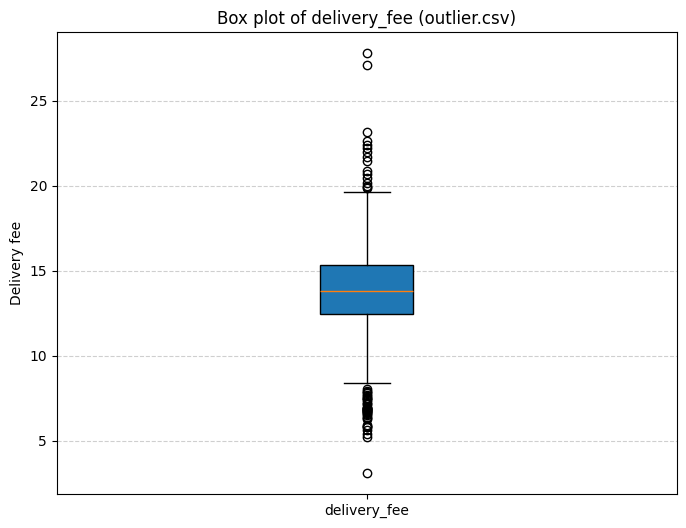

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.boxplot(outlier['delivery_fee'].dropna(), vert=True, patch_artist=True, labels=['delivery_fee'])
plt.ylabel('Delivery fee')
plt.title('Box plot of delivery_fee (outlier.csv)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

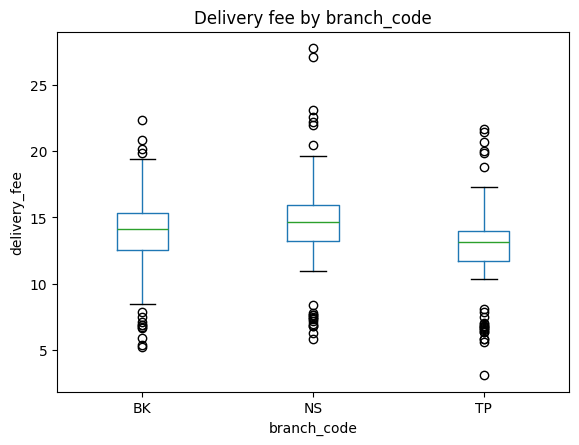

In [30]:
plt.figure(figsize=(8, 6))
outlier.boxplot(column="delivery_fee", by="branch_code", grid=False)
plt.title("Delivery fee by branch_code")
plt.suptitle("")
plt.xlabel("branch_code")
plt.ylabel("delivery_fee")
plt.show()

### 7.2 Branch-wise IQR rule

因为 fee model 是 branch-specific，outlier threshold 也按 branch 分开算。

In [31]:
flagged_frames = []
bounds = []

for branch_code, branch_rows in outlier_residuals.groupby("branch_code"):
    q1, q3 = branch_rows["abs_residual"].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    branch_flagged = branch_rows.copy()
    branch_flagged["outlier_bound"] = upper_bound
    branch_flagged["is_delivery_fee_outlier"] = branch_flagged["abs_residual"].gt(upper_bound)
    flagged_frames.append(branch_flagged)

    bounds.append(
        {
            "branch_code": branch_code,
            "q1_abs_residual": q1,
            "q3_abs_residual": q3,
            "upper_bound": upper_bound,
            "outlier_count": int(branch_flagged["is_delivery_fee_outlier"].sum()),
        }
    )

outlier_bounds = pd.DataFrame(bounds)
flagged_residuals = pd.concat(flagged_frames)
delivery_fee_outliers = flagged_residuals.loc[flagged_residuals["is_delivery_fee_outlier"]].sort_values(
    ["branch_code", "abs_residual"],
    ascending=[True, False],
)

display(outlier_bounds)
delivery_fee_outliers.head(10)

,branch_code,q1_abs_residual,q3_abs_residual,upper_bound,outlier_count
0,BK,0.0952,0.4126,0.8887,9
1,NS,0.1639,0.9099,2.0287,14
2,TP,0.1821,0.6801,1.4271,21


,order_id,branch_code,delivery_fee,customerHasloyalty?,is_weekend,time_code,distance_to_customer_KM,adjusted_delivery_fee,predicted_adjusted_fee,abs_residual,outlier_bound,is_delivery_fee_outlier
199,ORDX02124,BK,12.9103,1,1,0,9.1830,25.8205,16.7193,9.1012,0.8887,True
318,ORDA03445,BK,7.5113,0,0,1,8.8610,7.5113,14.7720,7.2607,0.8887,True
442,ORDK00636,BK,22.3731,0,0,2,8.3560,22.3731,15.3469,7.0262,0.8887,True
91,ORDK09590,BK,6.6534,0,0,0,8.3580,6.6534,13.1290,6.4756,0.8887,True
93,ORDK00865,BK,19.8712,0,0,1,7.7410,19.8712,13.5852,6.2860,0.8887,True
490,ORDK02256,BK,5.2169,0,0,0,5.6040,5.2169,10.2108,4.9939,0.8887,True
387,ORDX02830,BK,14.3142,0,0,2,3.4540,14.3142,10.1526,4.1616,0.8887,True
486,ORDX08202,BK,19.4176,0,1,2,10.4940,19.4176,20.3285,0.9109,0.8887,True
496,ORDA04575,BK,6.8752,1,0,0,8.0940,13.7503,12.8492,0.9011,0.8887,True
397,ORDZ10737,NS,27.7906,0,1,2,10.6220,27.7906,19.5435,8.2472,2.0287,True


# residual IQR check
删除标记出的 delivery_fee outliers，然后用保留 rows 重新训练 branch-specific models。

如果保留 rows 的 R2 仍不够接近 1，说明第一轮 IQR 没有删干净，需要进一步迭代检测。

In [32]:
outlier_issue = outlier["order_id"].isin(delivery_fee_outliers["order_id"])

removed_outliers = task.remove_rows(
    dataset="outlier",
    step="delivery_fee",
    issue_mask=outlier_issue,
    sample_columns=["branch_code", "delivery_fee", "customerHasloyalty?", "distance_to_customer_KM"],
)

outlier = task.frame("outlier")
removed_outliers

[outlier:delivery_fee] flagged=44, fixed=44, remaining=0, skipped_by_tracker=0
[outlier:delivery_fee] rows_before=500, rows_after=456


,order_id,branch_code,delivery_fee,customerHasloyalty?,distance_to_customer_KM
8,ORDZ01820,NS,27.0965,0,10.0060
10,ORDJ06997,TP,6.9212,0,11.1770
27,ORDY04830,TP,6.3737,0,8.6010
29,ORDZ09868,NS,22.6118,0,9.5880
54,ORDI00907,NS,21.9854,0,7.1110
57,ORDC01694,NS,22.2342,0,6.6690
63,ORDB04124,TP,6.4837,0,10.1990
71,ORDZ01558,NS,12.9249,1,9.6660
91,ORDK09590,BK,6.6534,0,8.3580
92,ORDB08727,TP,6.7547,0,7.9570


In [34]:
task.compare_with_saved_outputs()

[compare] current in-memory results checked against saved CSV files


,dataset,same_shape,same_columns,numeric_close
0,dirty,True,True,True
1,missing,True,True,True
2,outlier,True,True,True


In [35]:
task.export_all()

[export] Group024_dirty_data_solution.csv: rows=500, columns=12
[export] Group024_missing_data_solution.csv: rows=500, columns=12
[export] Group024_outlier_data_solution.csv: rows=456, columns=12


In [36]:
display(task.read_back_outputs())
task.step_log()

[read-back] exported CSV files parsed successfully


,file,rows,columns,missing_cells,same_columns
0,Group024_dirty_data_solution.csv,500,12,0,True
1,Group024_missing_data_solution.csv,500,12,0,True
2,Group024_outlier_data_solution.csv,456,12,0,True


,dataset,step,flagged,fixed,remaining,skipped_by_tracker
0,dirty,branch_code,37,37,0,0
1,dirty,date,37,37,0,0
2,dirty,order_type,37,37,0,0
3,dirty,customer_coordinates,41,41,0,0
4,dirty,order_items,37,37,0,0
5,dirty,order_price,37,37,0,0
6,dirty,distance_to_customer_KM,37,37,0,0
7,missing,branch_code,100,100,0,0
8,missing,distance_to_customer_KM,50,50,0,0
9,missing,delivery_fee,50,50,0,0
